# IMDB Movie Review Sentiment Analysis

## Machine Learning-Based Sentiment Classification Using TF-IDF, Logistic Regression and Linear SVM

In [ ]:
import pandas as pd
import numpy as np

# SECTION 1 — DATASET LOADING & UNDERSTANDING

In [ ]:
df = pd.read_csv('/content/IMDB Dataset.csv', engine='python')

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')


In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
print("Total number of reviews:", len(df))

Total number of reviews: 50000


In [ ]:
label_counts = df['sentiment'].value_counts()
label_percentages = df['sentiment'].value_counts(normalize=True) * 100
baseline = df['sentiment'].value_counts(normalize=True).max()

In [ ]:
print(f"Total reviews: {len(df)}")
print("\nLabel counts:")
print(label_counts)
print("\nLabel percentages:")
print(label_percentages)
print(f"\nMajority-class baseline: {baseline:.3f}")

Total reviews: 50000

Label counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Label percentages:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

Majority-class baseline: 0.500


The dataset contains 50,000 movie reviews with two columns: review text and sentiment label. The sentiment classes are evenly distributed, with 25,000 positive and 25,000 negative reviews. Therefore, the dataset is balanced and the majority-class baseline accuracy is 50%.


# SECTION 2 — DATA CLEANING & PREPROCESSING

In [ ]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 418


In [ ]:
df=df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:",df.shape)

Dataset shape after removing duplicates: (49582, 2)


In [ ]:
df["review"]=df["review"].str.strip()
df["sentiment"]=df["sentiment"].str.strip().str.lower()

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


Duplicate rows were removed to avoid repeated examples during model training and evaluation. The review and sentiment columns were also cleaned by removing extra spaces and standardizing sentiment labels to lowercase. After cleaning, the dataset contains 49,582 unique review-label records with no missing values.


# SECTION 3 — REVIEW LENGTH ANALYSIS

In [ ]:
df['word_count'] = df['review'].str.split().str.len()
df[['review', 'word_count']].head()

,review,word_count
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


In [ ]:
mean_word_count = df['word_count'].mean()
median_word_count = df['word_count'].median()
print(f"Mean word count: {mean_word_count:.2f}")
print(f"Median word count: {median_word_count:.2f}")

Mean word count: 231.35
Median word count: 173.00


In [ ]:
df['word_count'].value_counts().head(10)

,count
word_count,
127,384
123,377
124,360
133,355
129,351
130,345
128,343
126,339
131,335


In [ ]:
df["word_count"].describe()

,word_count
count,49582.000000
mean,231.350167
std,171.542020
min,4.000000
25%,126.000000
50%,173.000000
75%,281.000000
max,2470.000000


In [ ]:
df.groupby("sentiment")["word_count"].mean()

,word_count
sentiment,
negative,229.596607
positive,233.090620


In [ ]:
df.groupby("sentiment")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,24698.0,229.596607,165.103430,4.0,128.0,174.0,278.0,1522.0
positive,24884.0,233.090620,177.688169,10.0,125.0,172.0,284.0,2470.0


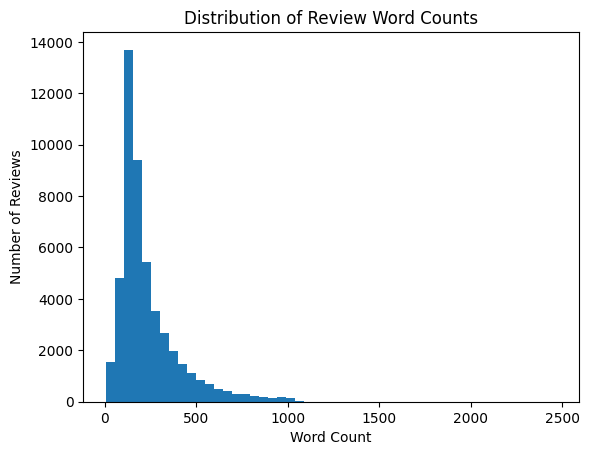

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["word_count"],bins=50)
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Word Counts")
plt.show()

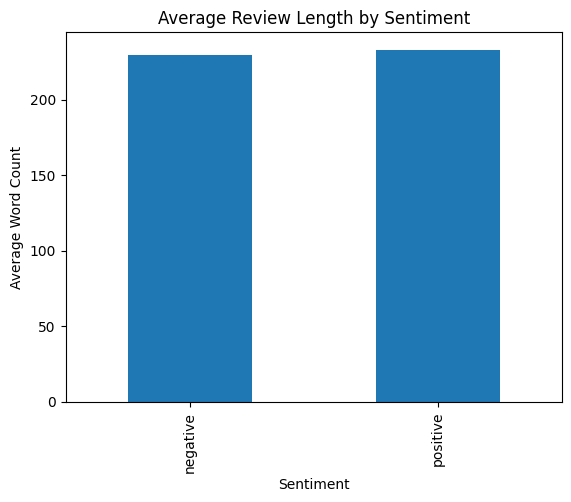

In [ ]:
df.groupby("sentiment")["word_count"].mean().plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.title("Average Review Length by Sentiment")
plt.show()

Review length was analyzed to understand the distribution of text in the dataset. The average review contains about 231 words, while the median is 173 words. Positive and negative reviews have very similar average lengths, suggesting that review length alone is unlikely to strongly distinguish the two sentiment classes.


# SECTION 4 — TEXT ANALYSIS

In [ ]:
from collections import Counter
import re
words=" ".join(df["review"]).lower()
words=re.findall(r"\b[a-z]+\b",words)
word_counts=Counter(words)
word_counts.most_common(20)

[('the', 662910),
 ('and', 322091),
 ('a', 320717),
 ('of', 287338),
 ('to', 266120),
 ('is', 209631),
 ('br', 200425),
 ('it', 189437),
 ('in', 185416),
 ('i', 174140),
 ('this', 149810),
 ('that', 142815),
 ('s', 124159),
 ('was', 94816),
 ('as', 91076),
 ('movie', 87276),
 ('for', 86821),
 ('with', 86717),
 ('but', 82923),
 ('film', 79148)]

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words=set(stopwords.words("english"))
words=[word for word in words if word not in stop_words]
Counter(words).most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('br', 200425),
 ('movie', 87276),
 ('film', 79148),
 ('one', 53205),
 ('like', 39843),
 ('good', 29547),
 ('time', 24906),
 ('even', 24668),
 ('would', 24401),
 ('story', 22971),
 ('really', 22923),
 ('see', 22823),
 ('well', 21107),
 ('much', 19151),
 ('bad', 18292),
 ('get', 18274),
 ('people', 18022),
 ('great', 18018),
 ('also', 17851),
 ('first', 17432)]

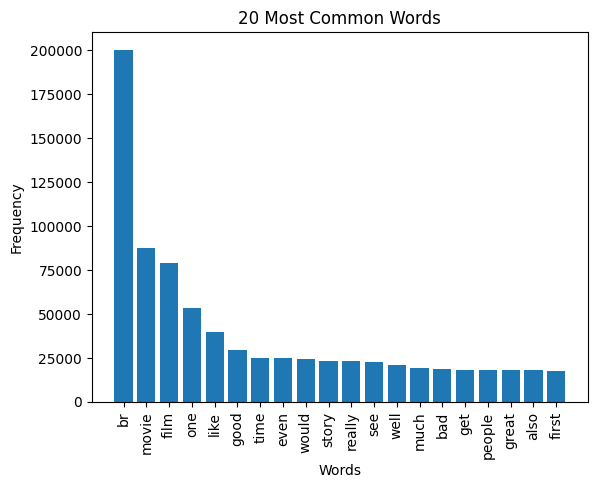

In [ ]:
common_words=Counter(words).most_common(20)
word_names=[x[0] for x in common_words]
word_values=[x[1] for x in common_words]

plt.bar(word_names,word_values)
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("20 Most Common Words")
plt.show()

In [ ]:
positive_words=" ".join(df[df["sentiment"]=="positive"]["review"]).lower()
positive_words=re.findall(r"\b[a-z]+\b",positive_words)
positive_words=[word for word in positive_words if word not in stop_words]
Counter(positive_words).most_common(20)

[('br', 97602),
 ('film', 41970),
 ('movie', 37660),
 ('one', 27210),
 ('like', 17651),
 ('good', 14966),
 ('story', 12898),
 ('great', 12889),
 ('time', 12701),
 ('well', 12683),
 ('see', 12225),
 ('also', 10761),
 ('really', 10706),
 ('would', 10547),
 ('even', 9573),
 ('first', 9186),
 ('much', 9175),
 ('people', 8685),
 ('love', 8658),
 ('best', 8480)]

In [ ]:
negative_words=" ".join(df[df["sentiment"]=="negative"]["review"]).lower()
negative_words=re.findall(r"\b[a-z]+\b",negative_words)
negative_words=[word for word in negative_words if word not in stop_words]
Counter(negative_words).most_common(20)

[('br', 102823),
 ('movie', 49616),
 ('film', 37178),
 ('one', 25995),
 ('like', 22192),
 ('even', 15095),
 ('good', 14581),
 ('bad', 14563),
 ('would', 13854),
 ('really', 12217),
 ('time', 12205),
 ('see', 10598),
 ('story', 10073),
 ('get', 10023),
 ('much', 9976),
 ('people', 9337),
 ('make', 9266),
 ('could', 9184),
 ('made', 8707),
 ('well', 8424)]

In [ ]:
positive_common=Counter(positive_words).most_common(10)
negative_common=Counter(negative_words).most_common(10)
print("Positive words:")
print(positive_common)
print("\nNegative words:")
print(negative_common)

Positive words:
[('br', 97602), ('film', 41970), ('movie', 37660), ('one', 27210), ('like', 17651), ('good', 14966), ('story', 12898), ('great', 12889), ('time', 12701), ('well', 12683)]

Negative words:
[('br', 102823), ('movie', 49616), ('film', 37178), ('one', 25995), ('like', 22192), ('even', 15095), ('good', 14581), ('bad', 14563), ('would', 13854), ('really', 12217)]


Word-frequency analysis was performed to identify commonly occurring terms in the reviews. Stop words were removed for this exploratory analysis so that more meaningful words could be observed. Positive and negative reviews were also analyzed separately to identify words associated with each sentiment.


# SECTION 5 — TEXT PREPROCESSING FOR MACHINE LEARNING

In [ ]:
df["cleaned_review"]=df["review"].str.lower()
df["cleaned_review"]=df["cleaned_review"].str.replace(r"[^a-z\s]","",regex=True)

In [ ]:
df["cleaned_review"]=df["cleaned_review"].str.replace(r"\s+"," ",regex=True).str.strip()

In [ ]:
df[["review","cleaned_review"]].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [ ]:
print("Total reviews:",len(df))
print("Missing cleaned reviews:",df["cleaned_review"].isnull().sum())

Total reviews: 49582
Missing cleaned reviews: 0


In [ ]:
df["label"]=df["sentiment"].map({"negative":0,"positive":1})

In [ ]:
df["label"].value_counts()

,count
label,
1,24884
0,24698


In [ ]:
X=df["cleaned_review"]
y=df["label"]

The review text was converted to lowercase and unnecessary non-alphabetic characters and extra whitespace were removed. The sentiment labels were converted into numerical values, where 0 represents negative sentiment and 1 represents positive sentiment. The cleaned review text and numerical labels were then prepared for machine-learning models.


# SECTION 6 — TRAIN/TEST SPLIT & TF-IDF

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print("Training reviews:",len(X_train))
print("Testing reviews:",len(X_test))

Training reviews: 39665
Testing reviews: 9917


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=10000)

In [ ]:
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)

In [ ]:
print("Training TF-IDF shape:",X_train_tfidf.shape)
print("Testing TF-IDF shape:",X_test_tfidf.shape)

Training TF-IDF shape: (39665, 10000)
Testing TF-IDF shape: (9917, 10000)


In [ ]:
print("Number of TF-IDF features:",len(vectorizer.get_feature_names_out()))

Number of TF-IDF features: 10000


The dataset was divided into training and testing sets using an 80:20 split with stratification to preserve the sentiment distribution. TF-IDF was used to convert the text into numerical features. The vectorizer was fitted only on the training data and then applied to the test data, preventing information leakage. A maximum of 10,000 TF-IDF features was used.


# SECTION 7 — MODEL BUILDING

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model=LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred=model.predict(X_test_tfidf)

In [ ]:
print("Predictions:",len(y_pred))

Predictions: 9917


# SECTION 8 — MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8916002823434507


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



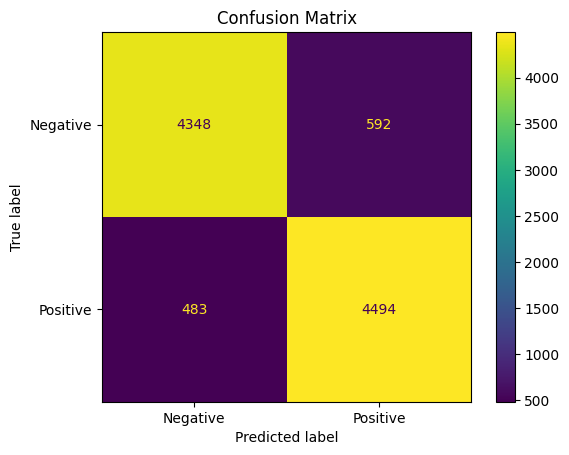

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative","Positive"]).plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report=classification_report(y_test,y_pred,output_dict=True)
print("Accuracy:",accuracy)
print("Negative F1-score:",report["0"]["f1-score"])
print("Positive F1-score:",report["1"]["f1-score"])

Accuracy: 0.8916002823434507
Negative F1-score: 0.8899805547026917
Positive F1-score: 0.8931730100367684


In [ ]:
results=pd.DataFrame({"Actual":y_test.values,"Predicted":y_pred})
results.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
5,1,1
6,0,0
7,0,0
8,1,1
9,0,0


In [ ]:
correct=(y_test.values==y_pred).sum()
incorrect=(y_test.values!=y_pred).sum()

print("Correct predictions:",correct)
print("Incorrect predictions:",incorrect)

Correct predictions: 8842
Incorrect predictions: 1075


# SECTION 9 — TESTING THE MODEL WITH NEW REVIEWS

In [ ]:
def predict_sentiment(review):
    review=review.lower()
    review=re.sub(r"[^a-z\s]","",review)
    review=re.sub(r"\s+"," ",review).strip()

    review_tfidf=vectorizer.transform([review])
    prediction=model.predict(review_tfidf)[0]

    if prediction==1:
        return "Positive"
    return "Negative"

In [ ]:
review="This movie was absolutely amazing and I really enjoyed it"
print("Review:",review)
print("Predicted Sentiment:",predict_sentiment(review))

Review: This movie was absolutely amazing and I really enjoyed it
Predicted Sentiment: Positive


In [ ]:
review="This movie was boring and disappointing and I did not enjoy it"
print("Review:",review)
print("Predicted Sentiment:",predict_sentiment(review))

Review: This movie was boring and disappointing and I did not enjoy it
Predicted Sentiment: Negative


In [ ]:
review=input("Enter a movie review: ")
print("Predicted Sentiment:",predict_sentiment(review))

Enter a movie review: The movie was excellent and marvellous and i liked it so much.
Predicted Sentiment: Positive


In [ ]:
reviews=[
    "The movie was excellent and entertaining",
    "The story was terrible and boring",
    "I loved the acting and the story",
    "The movie was a complete waste of time"
]
for review in reviews:
    print("Review:",review)
    print("Sentiment:",predict_sentiment(review))
    print()

Review: The movie was excellent and entertaining
Sentiment: Positive

Review: The story was terrible and boring
Sentiment: Negative

Review: I loved the acting and the story
Sentiment: Positive

Review: The movie was a complete waste of time
Sentiment: Negative



# SECTION 10 — MODEL COMPARISON & IMPROVEMENT

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm_model=LinearSVC()

In [ ]:
svm_model.fit(X_train_tfidf,y_train)

LinearSVC()

In [ ]:
svm_pred=svm_model.predict(X_test_tfidf)

In [ ]:
svm_accuracy=accuracy_score(y_test,svm_pred)
print("Logistic Regression Accuracy:",accuracy)
print("Linear SVM Accuracy:",svm_accuracy)

Logistic Regression Accuracy: 0.8916002823434507
Linear SVM Accuracy: 0.8873651305838459


In [ ]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      4940
           1       0.88      0.89      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [ ]:
comparison=pd.DataFrame({
    "Model":["Logistic Regression","Linear SVM"],
    "Accuracy":[accuracy,svm_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.891600
1,Linear SVM,0.887365


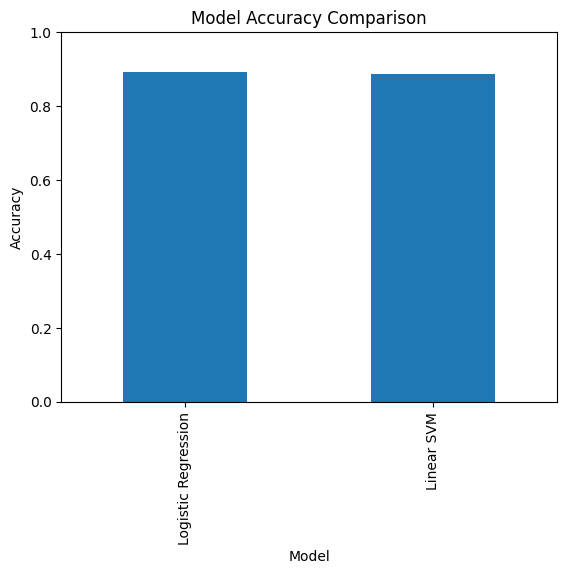

In [ ]:
comparison.plot(x="Model",y="Accuracy",kind="bar",legend=False)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [ ]:
if svm_accuracy>accuracy:
    best_model=svm_model
    best_accuracy=svm_accuracy
    print("Best Model: Linear SVM")
else:
    best_model=model
    best_accuracy=accuracy
    print("Best Model: Logistic Regression")

print("Best Accuracy:",best_accuracy)

Best Model: Logistic Regression
Best Accuracy: 0.8916002823434507


Two machine-learning models were compared using the same TF-IDF features: Logistic Regression and Linear SVM. Logistic Regression achieved 89.16% accuracy, while Linear SVM achieved 88.74%. Since Logistic Regression performed slightly better, it was selected as the best-performing model.


# SECTION 11 — FINAL MODEL SELECTION & SAVING

In [ ]:
print("Logistic Regression Accuracy:",accuracy)
print("Linear SVM Accuracy:",svm_accuracy)
print("Best Model Accuracy:",best_accuracy)

Logistic Regression Accuracy: 0.8916002823434507
Linear SVM Accuracy: 0.8873651305838459
Best Model Accuracy: 0.8916002823434507


In [ ]:
final_model=best_model

In [ ]:
final_pred=final_model.predict(X_test_tfidf)
final_accuracy=accuracy_score(y_test,final_pred)
print("Final Model Accuracy:",final_accuracy)

Final Model Accuracy: 0.8916002823434507


In [ ]:
print(classification_report(y_test,final_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [ ]:
import joblib
joblib.dump(final_model,"sentiment_model.pkl")
joblib.dump(vectorizer,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
import os
print("Model saved:",os.path.exists("sentiment_model.pkl"))
print("Vectorizer saved:",os.path.exists("tfidf_vectorizer.pkl"))

Model saved: True
Vectorizer saved: True


Logistic Regression was selected as the final model because it achieved the highest accuracy among the tested models. The trained model and TF-IDF vectorizer were saved using Joblib so that they can be reused later without retraining the entire system.


# SECTION 12 — FINAL PROJECT SUMMARY & RESULTS

In [ ]:
print("Total Reviews:",len(df))
print("Positive Reviews:",(df["sentiment"]=="positive").sum())
print("Negative Reviews:",(df["sentiment"]=="negative").sum())

Total Reviews: 49582
Positive Reviews: 24884
Negative Reviews: 24698


In [ ]:
print("Training Reviews:",len(X_train))
print("Testing Reviews:",len(X_test))
print("TF-IDF Features:",X_train_tfidf.shape[1])

Training Reviews: 39665
Testing Reviews: 9917
TF-IDF Features: 10000


In [ ]:
print("Logistic Regression Accuracy:",accuracy)
print("Linear SVM Accuracy:",svm_accuracy)
print("Final Model Accuracy:",final_accuracy)

Logistic Regression Accuracy: 0.8916002823434507
Linear SVM Accuracy: 0.8873651305838459
Final Model Accuracy: 0.8916002823434507


In [ ]:
final_results=pd.DataFrame({
    "Model":["Logistic Regression","Linear SVM","Final Model"],
    "Accuracy":[accuracy,svm_accuracy,final_accuracy]
})

final_results

,Model,Accuracy
0,Logistic Regression,0.891600
1,Linear SVM,0.887365
2,Final Model,0.891600


In [ ]:
print("Project: Movie Review Sentiment Analysis")
print("Dataset Size:",len(df))
print("Final Model:",type(final_model).__name__)
print("Final Accuracy:",round(final_accuracy*100,2),"%")

Project: Movie Review Sentiment Analysis
Dataset Size: 49582
Final Model: LogisticRegression
Final Accuracy: 89.16 %


## Conclusion

The project successfully developed a machine-learning-based sentiment classifier for IMDB movie reviews. TF-IDF was used to convert review text into numerical features, followed by Logistic Regression and Linear SVM models. Logistic Regression achieved the best accuracy of 89.16%, outperforming Linear SVM at 88.74%. The final model was saved along with the TF-IDF vectorizer for future use.
